## **Projekat iz predmeta Astrostatistika**

### **Uticaj spektralnog tipa zvezde na klasifikaciju egzoplaneta u habitabilnoj zoni prema Kopparapu modelu** 

### Letnji semestar 2026. godine

Student: Tamara Brujić

Mentor: prof. dr Anđelka Kovačević


Jedno od centralnih pitanja u proučavanju egzoplaneta jeste određivanje uslova pod kojima bi planeta mogla da poseduje tečnu vodu na površini. U tom kontekstu uvodi se pojam habitabilne zone, odnosno oblasti oko zvezde u kojoj planeta, pod odgovarajućim atmosferskim uslovima, prima dovoljnu količinu zračenja da voda može ostati u tečnom stanju. Habitabilna zona ne predstavlja direktan dokaz nastanjivosti planete, već samo prvi kriterijum za izdvajanje potencijalno interesantnih kandidata.

Položaj habitabilne zone zavisi prvenstveno od osobina matične zvezde, naročito od njene luminoznosti i efektivne temperature. Zbog toga se granice habitabilne zone ne mogu odrediti samo na osnovu orbitalne udaljenosti planete. Planeta na udaljenosti od $1 AU$ može biti u habitabilnoj zoni oko zvezde slične Suncu, ali ne i oko znatno hladnije ili toplije zvezde. U ovom radu koristi se Kopparapu model, koji daje analitički opis granica habitabilne zone preko efektivnog zvezdanog fluksa. Model omogućava da se za svaku zvezdu, na osnovu njene efektivne temperature i luminoznosti, izračunaju unutrašnje i spoljašnje granice konzervativne i optimistične habitabilne zone.

## **Kopparapu model**

Kopparapu uvodi model koji računa granice habitabilne zone koji se u prvoj iteraciji predstavlja preko fluksa izraženog putem polinomijalnog razvoja četvrtog stepena čiji je izraz: (Kopparapu et al., 2014.) 

$$S_{eff} = S_{eff, \cdot} + aT_* + bT_{*}^2 + cT_{*}^3 + dT_{*}^4$$

gde je:

$$T_{*} = T_{eff} - 5780$$

posle čega se fluks prevodi u udaljenost, odnosno habitabilnu zonu:

$$d = \sqrt{\frac{L_*/L_{\cdot}}{S_{eff}}}$$

Na početku koda definišu se koeficijenti Kopparapu modela potrebni za računanje efektivnog zvezdanog fluksa na granicama habitabilne zone. Model ne daje direktno udaljenost granice u astronomskim jedinicama gde je efektivni fluks $S_{eff}$ izražen u jedinicama Sunčevog fluksa. Za svaku granicu habitabilne zone koristi se poseban skup koeficijenata $(S_{eff,\odot}, a, b, c, d)$, koji ulaze u izraz fluksa. Ova promenljiva predstavlja odstupanje efektivne temperature zvezde od Sunčeve efektivne temperature, pa se za zvezdu Sunčevog tipa izraz svodi na referentnu vrednost $(S_{eff,\odot})$.

U kodu su koeficijenti organizovani u liste, pri čemu svaka pozicija u listi odgovara jednoj granici habitabilne zone: Recent Venus, Runaway Greenhouse, Maximum Greenhouse, Early Mars, kao i dodatnim Runaway Greenhouse granicama za planete različitih masa. U ovom radu za optimističnu habitabilnu zonu koriste se granice Recent Venus i Early Mars, dok se za konzervativnu habitabilnu zonu koriste Runaway Greenhouse i Maximum Greenhouse. Nakon izračunavanja fluksa, granice se pretvaraju u udaljenosti.

In [2]:
#************************************************************************************
# This code calculates habitable zone 'fluxes' using the expression given in the 
# Kopparapu et al.(2014) paper. The corresponding output file is 'HZs.dat'. 
# It also generates a file 'HZ_coefficients.dat' that gives the coefficients for 
# the analytical expression.
#
# Ravi kumar Kopparapu April 19 2014
#
# Translated to python code by John Armstrong (jcarmstrong@weber.edu) 04 June 2014
#************************************************************************************
#************************************************************************************
# Output files.

hzdat = open('HZs.dat', 'w')
hzcoeff = open('HZ_coefficients.dat', 'w')

#************************************************************************************
# Coeffcients to be used in the analytical expression to calculate habitable zone flux 
# boundaries

seff = [0,0,0,0,0,0]
seffsun  = [1.776,1.107, 0.356, 0.320, 1.188, 0.99] 
a = [2.136e-4, 1.332e-4, 6.171e-5, 5.547e-5, 1.433e-4, 1.209e-4]
b = [2.533e-8, 1.580e-8, 1.698e-9, 1.526e-9, 1.707e-8, 1.404e-8]
c = [-1.332e-11, -8.308e-12, -3.198e-12, -2.874e-12, -8.968e-12, -7.418e-12]
d = [-3.097e-15, -1.931e-15, -5.575e-16, -5.011e-16, -2.084e-15, -1.713e-15]


#************************************************************************************
# Writing coefficients into 'HZ_coefficients.dat' file

hzcoeff.write('# The coefficients are as follows. The columns, i, are arranged according to\n')
hzcoeff.write('# the HZ limits given in the paper.\n')
hzcoeff.write('#\n')
hzcoeff.write('# i = 1 --> Recent Venus\n')
hzcoeff.write('# i = 2 --> Runaway Greenhouse\n')
hzcoeff.write('# i = 3 --> Maximum Greenhouse\n')
hzcoeff.write('# i = 4 --> Early Mars\n')
hzcoeff.write('# i = 5 --> Runaway Greenhouse for 5 ME\n')
hzcoeff.write('# i = 6 --> Runaway Greenhouse for 0.1 ME\n')

hzcoeff.write('# First row: S_effSun(i)\n')
hzcoeff.write('# Second row: a(i)\n')
hzcoeff.write('# Third row:  b(i)\n')
hzcoeff.write('# Fourth row: c(i)\n')
hzcoeff.write('# Fifth row:  d(i)\n')
hzcoeff.write('   '+'{:6.6E}'.format(seffsun[0]) + '  ' +
              '{:6.6E}'.format(seffsun[1]) + '  ' +
              '{:6.6E}'.format(seffsun[2]) + '  ' +
              '{:6.6E}'.format(seffsun[3]) + '  ' +
              '{:6.6E}'.format(seffsun[4]) + '  ' +
              '{:6.6E}'.format(seffsun[5]) + '  ' +
              '\n')
hzcoeff.write('   '+'{:6.6E}'.format(a[0]) + '  ' +
              '{:6.6E}'.format(a[1]) + '  ' +
              '{:6.6E}'.format(a[2]) + '  ' +
              '{:6.6E}'.format(a[3]) + '  ' +
              '{:6.6E}'.format(a[4]) + '  ' +
              '{:6.6E}'.format(a[5]) + '  ' +
              '\n')
hzcoeff.write('   '+'{:6.6E}'.format(b[0]) + '  ' +
              '{:6.6E}'.format(b[1]) + '  ' +
              '{:6.6E}'.format(b[2]) + '  ' +
              '{:6.6E}'.format(b[3]) + '  ' +
              '{:6.6E}'.format(b[4]) + '  ' +
              '{:6.6E}'.format(b[5]) + '  ' +
              '\n')
hzcoeff.write('   '+'{:6.5e}'.format(c[0]) + '  ' +
              '{:6.5e}'.format(c[1]) + '  ' +
              '{:6.5e}'.format(c[2]) + '  ' +
              '{:6.5e}'.format(c[3]) + '  ' +
              '{:6.5e}'.format(c[4]) + '  ' +
              '{:6.5e}'.format(c[5]) + '  ' +
              '\n')
hzcoeff.write('   '+'{:6.5e}'.format(d[0]) + '  ' +
              '{:6.5e}'.format(d[1]) + '  ' +
              '{:6.5e}'.format(d[2]) + '  ' +
              '{:6.5e}'.format(d[3]) + '  ' +
              '{:6.5e}'.format(d[4]) + '  ' +
              '{:6.5e}'.format(d[5]) + '  ' +
              '\n')

#************************************************************************************
# Calculating HZ fluxes for stars with 2600 K < T_eff < 7200 K. The output file is
# 'HZ_fluxes.dat'

teff  = 2600.0
hzdat.write('#  Teff(K)        Recent        Runaway        Maximum        Early        5ME Runaway   0.1ME Runaway\n')
hzdat.write('#                 Venus         Greenhouse     Greenhouse     Mars         Greenhouse    Greenhouse\n')

starTemp = []
recentVenus = []
runawayGreenhouse = []
maxGreenhouse = []
earlyMars = []
fivemeRunaway = []
tenthmeRunaway = []

while(teff <= 7201.0): 
  tstar = teff - 5780.0
  for i in range(len(a)):
     seff[i] = seffsun[i] + a[i]*tstar + b[i]*tstar**2 + c[i]*tstar**3 + d[i]*tstar**4

  starTemp.append(teff)
  recentVenus.append(seff[0])
  runawayGreenhouse.append(seff[1])
  maxGreenhouse.append(seff[2])
  earlyMars.append(seff[3])
  fivemeRunaway.append(seff[4])
  tenthmeRunaway.append(seff[5])
     
  hzdat.write('   '+'{:6.0f}'.format(teff) + '      ' +
              '{:6.6E}'.format(seff[0]) + '      ' +
              '{:6.6E}'.format(seff[1]) + '     ' +
              '{:6.6E}'.format(seff[2]) + '   ' +
              '{:6.6E}'.format(seff[3]) + ' ' +
              '{:6.6E}'.format(seff[4]) + ' ' +
              '{:6.6E}'.format(seff[5]) + '  ' +
              '\n')
  teff = teff + 200.0

print ('************************************************************')
print ('')
print ('The HZ coefficients are printed in HZ_coefficients.dat file.')
print ('HZs for stars with 2600 K <= Teff <=7200 K is in HZs.dat file.')
print ('')
print ('************************************************************')

hzdat.close()
hzcoeff.close()

************************************************************

The HZ coefficients are printed in HZ_coefficients.dat file.
HZs for stars with 2600 K <= Teff <=7200 K is in HZs.dat file.

************************************************************


## **Računanje habitabilne zone iz kataloga Nasa Exoplanet Archive**

Podaci korišćeni dalje u radu su preuzeti iz _NASA Exoplanet Archive_ kataloga, iz tabele _Planetary Systems Composite Data_. Za svaku planetu korišćeni su parametri potrebni za primenu Kopparapu modela: efektivna temperatura zvezde, zvezdana luminoznost i velika poluosa orbite planete. Nakon čišćenja podataka i uklanjanja objekata sa parametrima koji nedostaju od gore navedenih, za svaku planetu izračunate su granice habitabilne zone i određeno je da li pripada konzervativnoj ili optimističnoj habitabilnoj zoni.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astroquery
import requests
import pandas as pd
import io

In [4]:
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive

#Učitavamo PSCompPars tabelu: jedan red po planeti
tab = NasaExoplanetArchive.query_criteria(
    table="pscomppars",
    select="pl_name,hostname,pl_orbsmax,pl_orbsmaxerr1,pl_orbsmaxerr2,pl_rade,pl_bmasse,st_teff,st_tefferr1,st_tefferr2,st_lum,st_lumerr1,st_lumerr2,st_mass,st_rad,st_spectype"
)

df = tab.to_pandas()

#df.info()
df.head()

,pl_name,hostname,pl_orbsmax,pl_orbsmaxerr1,pl_orbsmaxerr2,pl_rade,pl_bmasse,st_teff,st_tefferr1,st_tefferr2,st_lum,st_lumerr1,st_lumerr2,st_mass,st_rad,st_spectype
0,Kepler-1167 b,Kepler-1167,0.01750,NaN,NaN,1.710000,3.570,4971.0,96.57,-125.10,-0.53589,NaN,NaN,0.790,0.750,
1,Kepler-1740 b,Kepler-1740,0.07790,NaN,NaN,3.323214,11.000,5705.0,76.00,-76.00,-0.07942,NaN,NaN,0.943,0.905,
2,Kepler-1581 b,Kepler-1581,0.06865,0.00073,-0.00073,0.800000,0.437,6022.0,81.89,-66.79,0.39085,0.02171,-0.03818,1.120,1.230,
3,Kepler-644 b,Kepler-644,0.04641,0.00029,-0.00029,3.150000,10.100,6747.0,156.03,-238.58,0.71041,NaN,NaN,1.490,1.810,
4,Kepler-1752 b,Kepler-1752,0.26980,NaN,NaN,4.540605,18.700,5446.0,162.00,-162.00,-0.39819,NaN,NaN,0.824,0.821,


In [5]:
#Izbacuju se svi redovi koji nemaju neku od ove tri vrednosti koje nam trebaju za dalji račun
df_clean = df.dropna(subset=["st_teff", "st_lum", "pl_orbsmax"]).copy()

#Pretvaramo log-luminoznost u L/Lsun
df_clean["st_lum_solar"] = 10 ** df_clean["st_lum"]

#Kopparapu model najčešće koristimo u opsegu oko 2600-7200K
df_clean = df_clean[
    (df_clean["st_teff"] >= 2600) &
    (df_clean["st_teff"] <= 7200)
].copy()

#Uklanjamo vrednosti koje fizički nemaju smisla ako postoje
df_clean = df_clean[
    (df_clean["st_lum_solar"] > 0) &
    (df_clean["pl_orbsmax"] > 0)
].copy()

print("Broj planeta posle čišćenja:", len(df_clean))
#df_clean.head()

Broj planeta posle čišćenja: 5496


In [6]:
#Kapparapu model

# Koeficijenti iz Kopparapu et al. modela
# Važe za različite granice habitabilne zone

import numpy as np

kopparapu_coeffs = {
#Venera je verovatno izgubila uslove za tečnu vodu relativno rano, pa se njen nekadašnji položaj koristi kao empirijska, optimistična unutrašnja granica ali je verovatno prevruće
    "recent_venus": {
        "Seff_sun": 1.776,
        "a": 2.136e-4,
        "b": 2.533e-8,
        "c": -1.332e-11,
        "d": -3.097e-15
    },
#Konzervativna unutrasnja granica, uslov kada planeta prima toliko zračenja da vodena para pojačava efekat staklene bašte, temperatura raste, isparava još vode, i proces teži da učini sistem nestabilanim
    "runaway_greenhouse": {
        "Seff_sun": 1.107,
        "a": 1.332e-4,
        "b": 1.580e-8,
        "c": -8.308e-12,
        "d": -1.931e-15
    },
#Ovo je konzervativna spoljašnja granica, jer na spoljašnjoj ivici HZ planeta prima manje zračenja. Da bi ostala dovoljno topla, potreban joj je jak efekat staklene bašte, najčešće zbog CO2
    "maximum_greenhouse": {
        "Seff_sun": 0.356,
        "a": 6.171e-5,
        "b": 1.698e-9,
        "c": -3.198e-12,
        "d": -5.575e-16
    },
#Ovo je optimistična spoljašnja granica
    "early_mars": {
        "Seff_sun": 0.320,
        "a": 5.547e-5,
        "b": 1.526e-9,
        "c": -2.874e-12,
        "d": -5.011e-16
    },
#Specifične granice navedene u originalnom kodu, za različite amse planeta, 5 i 0.1 mase Zemlje
    "runaway_greenhouse_5Me": {
        "Seff_sun": 1.188,
        "a": 1.433e-4,
        "b": 1.707e-8,
        "c": -8.968e-12,
        "d": -2.084e-15
    },
    "runaway_greenhouse_01Me": {
        "Seff_sun": 0.99,
        "a": 1.209e-4,
        "b": 1.404e-8,
        "c": -7.418e-12,
        "d": -1.713e-15
    }
}

In [7]:
#fluks koji planeta prima od svoje zvezde, izražen u jedinicama Sunčevog fluksa koji Zemlja prima danas prema Kopparapu modelu.
def kopparapu_seff(teff, limit_name):

#teff: efektivna temperatura zvezde u K
#limit_name: ime granice iz kopparapu_coeffs
    
    coeff = kopparapu_coeffs[limit_name]
    T_star = teff - 5780.0
    
    S_eff = (
        coeff["Seff_sun"]
        + coeff["a"] * T_star
        + coeff["b"] * T_star**2
        + coeff["c"] * T_star**3
        + coeff["d"] * T_star**4
    )
    
    return S_eff

#Moramo da radimo sa efektivnom temperaturom a ne samo ukupnom luminoznošću jer zrače u različitim delovima spektra pa i planeta apsorbuje to zračenje drugačije

#Računa udaljenost HZ granice u AU.
def hz_distance(luminosity, teff, limit_name):

    #luminosity: luminoznost zvezde u jedinicama Sunčeve luminoznosti
    #teff: efektivna temperatura zvezde u K
    #limit_name: ime Kopparapu granice
    
    seff = kopparapu_seff(teff, limit_name)
    distance = np.sqrt(luminosity / seff)

    return distance

In [8]:
#Za svaku planetu sada uzimamo učitane vrednosti iz arhive za luminoznost i temperaturu zvezde nakon čega prethodno definisane 4 HZ računamo za svaku ponaosob na kojoj je udaljenosti
df_clean["hz_recent_venus"] = hz_distance(
    df_clean["st_lum_solar"],
    df_clean["st_teff"],
    "recent_venus"
)

df_clean["hz_runaway_greenhouse"] = hz_distance(
    df_clean["st_lum_solar"],
    df_clean["st_teff"],
    "runaway_greenhouse"
)

df_clean["hz_maximum_greenhouse"] = hz_distance(
    df_clean["st_lum_solar"],
    df_clean["st_teff"],
    "maximum_greenhouse"
)

df_clean["hz_early_mars"] = hz_distance(
    df_clean["st_lum_solar"],
    df_clean["st_teff"],
    "early_mars"
)

In [9]:
#Klasifikacija planeta, pripadanje HZ
#Uzimamo vrednosti velike poluose učitanih egzoplaneta
a_planet = df_clean["pl_orbsmax"]

#Nalazi se u granici konzervativne hz, da ili ne
df_clean["in_conservative_hz"] = (
    (a_planet >= df_clean["hz_runaway_greenhouse"]) &
    (a_planet <= df_clean["hz_maximum_greenhouse"])
)

#U granici optimističke hz
df_clean["in_optimistic_hz"] = (
    (a_planet >= df_clean["hz_recent_venus"]) &
    (a_planet <= df_clean["hz_early_mars"])
)

#Pošto imamo vrednosti koje su definisane kao da ili ne, konkretizujemo tekstutualno kroz uslove koji se nadovezuju kojoj kategoriji habitabilne zone pripada planeta
def classify_hz(row):
    a = row["pl_orbsmax"]

    if row["in_conservative_hz"]:
        return "conservative HZ"
    elif row["in_optimistic_hz"]:
        return "optimistic HZ only"
    elif a < row["hz_recent_venus"]:
        return "too close"
    elif a > row["hz_early_mars"]:
        return "too far"
    else:
        return "between boundaries"


df_clean["hz_class"] = df_clean.apply(classify_hz, axis=1)
#df_clean["in_conservative_hz"].mean() * 100

In [10]:
#Čuvam tabelu sa planetama koje su ispunile uslov da se na njih može primeniti model
df_clean.to_csv("exoplanets_kopparapu_hz.csv", index=False)

findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.


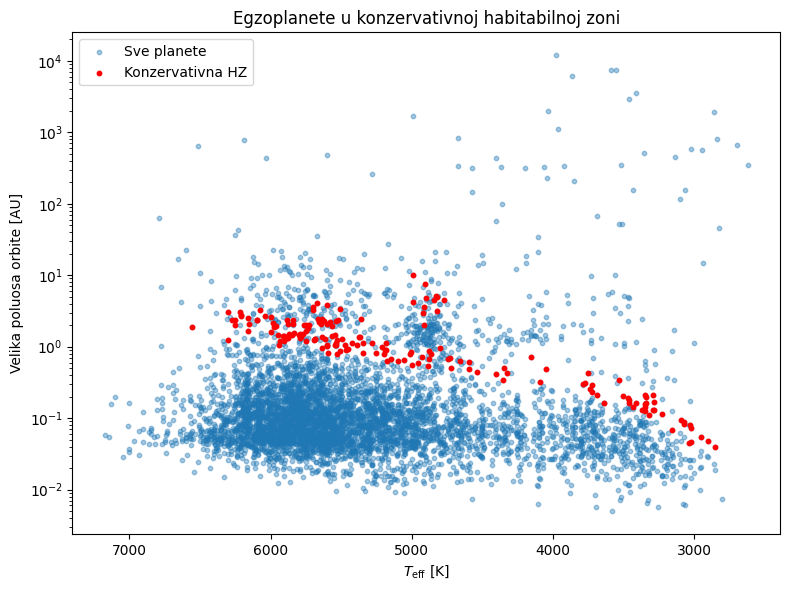

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_clean["st_teff"],
    df_clean["pl_orbsmax"],
    s=10,
    alpha=0.4,
    label="Sve planete"
)

plt.scatter(
    df_clean.loc[df_clean["in_conservative_hz"], "st_teff"],
    df_clean.loc[df_clean["in_conservative_hz"], "pl_orbsmax"],
    s=10,
    color = 'red',
    label="Konzervativna HZ"
)

plt.xlabel(r"$T_{\mathrm{eff}}$ [K]")
plt.ylabel("Velika poluosa orbite [AU]")
plt.yscale("log")
plt.gca().invert_xaxis()
plt.legend()
plt.title("Egzoplanete u konzervativnoj habitabilnoj zoni")

plt.tight_layout()
plt.show()

Može se primetiti da se kandidati za konzervativnu HZ ne nalaze na jednoj fiksnoj orbitalnoj udaljenosti, već prate zavisnost od efektivne temperature zvezde. Kod toplijih zvezda, odnosno zvezda sa većim $T_{eff}$, konzervativna habitabilna zona nalazi se na većim orbitalnim udaljenostima. Kod hladnijih zvezda, naročito M tipa, habitabilna zona je pomerena bliže zvezdi, pa se crvene tačke pojavljuju na manjim vrednostima velike poluose. To je očekivano, jer hladnije zvezde imaju manju luminoznost, pa planeta mora biti bliže zvezdi da bi primila dovoljno zračenja za uslove habitabilne zone.

Takođe se vidi da je većina detektovanih planeta smeštena na malim orbitalnim udaljenostima, ispod približno $0.1 – 0.2AU$. Veliki broj tih planeta nije označen kao HZ kandidat, što znači da su za svoje zvezde uglavnom preblizu unutrašnjoj granici habitabilne zone.

In [12]:
#Broj planeta pre i posle čišćenja podataka
n_total_original = len(df)
n_after_dropna = len(df_clean)
n_removed_missing = n_total_original - n_after_dropna

#Broj planeta u različitim kategorijama HZ
n_conservative = df_clean["in_conservative_hz"].sum()

n_optimistic_only = (
    df_clean["in_optimistic_hz"] &        #One koje su u optimističkoj ali izbacuje one iz konzervativne
    ~df_clean["in_conservative_hz"]      
).sum()

n_not_hz = (~df_clean["in_optimistic_hz"]).sum()    #Broji sve planete koje nisu u optimističkoj zoni

#Tabela sa rezultatima
tabela = pd.DataFrame({
    "Kategorija": [
        "Konzervativna HZ",
        "Samo optimistična HZ",
        "Van habitabilne zone",
        "Izbačeno zbog nedostajućih podataka"
    ],
    "Broj planeta": [
        n_conservative,
        n_optimistic_only,
        n_not_hz,
        n_removed_missing
    ]
})

tabela["Procenat [%]"] = [
    np.round(100 * n_conservative / n_after_dropna, 2),
    np.round(100 * n_optimistic_only / n_after_dropna, 2),
    np.round(100 * n_not_hz / n_after_dropna, 2),
    np.round(100 * n_removed_missing / n_total_original, 2)
]

print(tabela)

                            Kategorija  Broj planeta  Procenat [%]
0                     Konzervativna HZ           177          3.22
1                 Samo optimistična HZ            89          1.62
2                 Van habitabilne zone          5230         95.16
3  Izbačeno zbog nedostajućih podataka           795         12.64


## **Bootstrap analiza udela planeta u habitabilnoj zoni**

Sama klasifikacija planeta u konzervativnu ili optimističnu habitabilnu zonu daje samo jednu vrednost udela kandidata u posmatranom uzorku. Međutim, pošto radimo sa konačnim katalogom detektovanih egzoplaneta, taj udeo ne treba posmatrati kao apsolutno tačnu vrednost. Kada bi se uzorak planeta malo promenio, na primer zbog novih otkrića, drugačijeg izbora podataka ili uklanjanja pojedinih objekata, dobijeni procenat planeta u habitabilnoj zoni mogao bi se blago promeniti. Zbog toga je potrebno proceniti koliko je rezultat stabilan u odnosu na promene uzorka.

Ideja bootstrap metode je da se iz postojećeg očišćenog uzorka N planeta nasumično izvlači novi uzorak koji je iste veličine ali sa ponavljanjem. Za njega se potom računa ponovo udeo HZ planeta i pošto se to iterira mnogo puta dobija se raspodela mogućih vrednosti udela. Iz te raspodele mogu se proceniti standardna greška i interval poverenja za udeo HZ kandidata.

Ovaj korak je važan jer uvodi statističku neodređenost u rezultat Kopparapu klasifikacije. Umesto da se zaključi samo koliki procenat planeta pripada habitabilnoj zoni, bootstrap analiza omogućava da se proceni koliko je taj procenat pouzdan i da li je razlika između konzervativne i optimistične definicije habitabilne zone stabilna u odnosu na promene koje nastaju pri ponovnom uzorkovanju podataka.

In [13]:
#Definisanje funkcije 
def bootstrap_fraction(data, column, n_bootstrap):
    
    n = len(data)
    bootstrap_values = []

    for i in range(n_bootstrap):
        sample = data.sample(
            n=n,
            replace=True
        )

        fraction = sample[column].mean()
        bootstrap_values.append(fraction)

    return np.array(bootstrap_values)

In [14]:
#Njena primena na konzervativnu i optimističnu HZ
boot_conservative = bootstrap_fraction(
    df_clean,
    "in_conservative_hz",
    n_bootstrap=5000,
)

boot_optimistic = bootstrap_fraction(
    df_clean,
    "in_optimistic_hz",
    n_bootstrap=5000,
)

In [15]:
def summarize_bootstrap(bootstrap_values):
    
    #Iz bootstrap raspodele računa srednju vrednost, standardnu devijaciju i 95%-ti interval pouzdanosti.
    

    mean_value = np.mean(bootstrap_values)
    std_value = np.std(bootstrap_values, ddof=1)

    lower_95 = np.percentile(bootstrap_values, 2.5)
    upper_95 = np.percentile(bootstrap_values, 97.5)

    return mean_value, std_value, lower_95, upper_95

In [16]:
cons_mean, cons_std, cons_low, cons_high = summarize_bootstrap(boot_conservative)
opt_mean, opt_std, opt_low, opt_high = summarize_bootstrap(boot_optimistic)


bootstrap_summary = pd.DataFrame({
    "Kategorija": [
        "Konzervativna HZ",
        "Optimistična HZ"
    ],
    "Udeo [%]": [
        100*cons_mean,
        100*opt_mean
    ],
    "Bootstrap std [%]": [
        100*cons_std,
        100*opt_std
    ],
    "95% CI donja granica [%]": [
        100*cons_low,
        100*opt_low
    ],
    "95% CI gornja granica [%]": [
        100*cons_high,
        100*opt_high
    ]
})

np.round(bootstrap_summary, 2)

,Kategorija,Udeo [%],Bootstrap std [%],95% CI donja granica [%],95% CI gornja granica [%]
0,Konzervativna HZ,3.22,0.24,2.77,3.69
1,Optimistična HZ,4.84,0.29,4.28,5.40


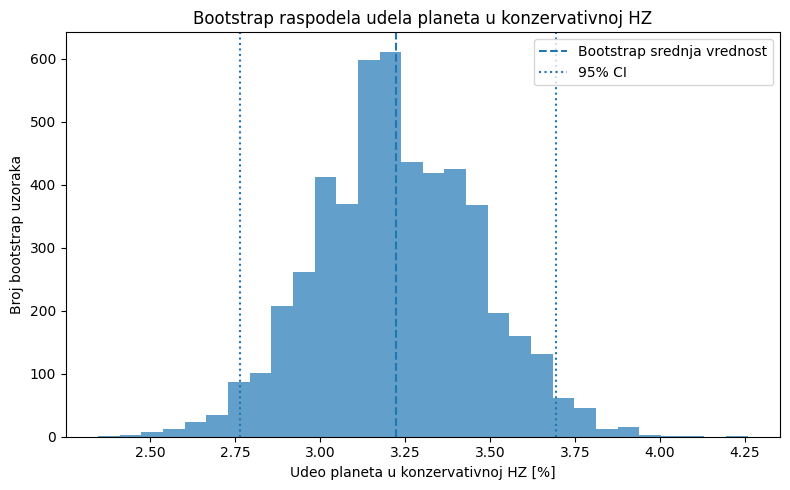

In [17]:
#Konzervativna
plt.figure(figsize=(8, 5))

plt.hist(100 * boot_conservative, bins=30, alpha=0.7)

plt.axvline(100 * cons_mean, linestyle="--", label="Bootstrap srednja vrednost")
plt.axvline(100 * cons_low, linestyle=":", label="95% CI")
plt.axvline(100 * cons_high, linestyle=":")

plt.xlabel("Udeo planeta u konzervativnoj HZ [%]")
plt.ylabel("Broj bootstrap uzoraka")
plt.title("Bootstrap raspodela udela planeta u konzervativnoj HZ")
plt.legend()

plt.tight_layout()
plt.show()

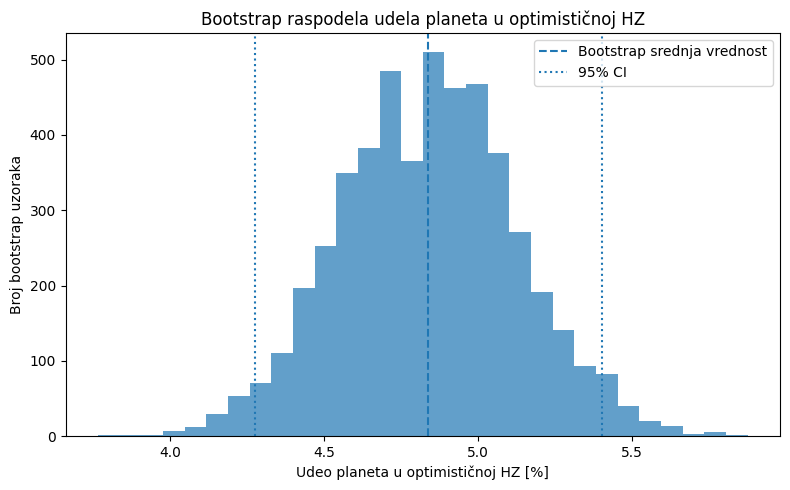

In [18]:
plt.figure(figsize=(8, 5))

plt.hist(100 * boot_optimistic, bins=30, alpha=0.7)

plt.axvline(100 * opt_mean, linestyle="--", label="Bootstrap srednja vrednost")
plt.axvline(100 * opt_low, linestyle=":", label="95% CI")
plt.axvline(100 * opt_high, linestyle=":")

plt.xlabel("Udeo planeta u optimističnoj HZ [%]")
plt.ylabel("Broj bootstrap uzoraka")
plt.title("Bootstrap raspodela udela planeta u optimističnoj HZ")
plt.legend()

plt.tight_layout()
plt.show()

Dobijene bootstrap raspodele su centrirane oko istih vrednosti koje su dobijene direktnom Kopparapu klasifikacijom: $3.22\%$ za konzervativnu HZ i $4.84\%$ za optimističnu HZ. To pokazuje da bootstrap analiza ne menja osnovni rezultat modela, već mu dodaje procenu statističke neizvesnosti.

Za konzervativnu HZ dobijena je bootstrap standardna devijacija od $0.24\%$, dok $95\%$ interval pouzdanosti iznosi od $2.77\%$ do $3.69\%$. Za optimističnu HZ standardna devijacija je $0.29\%$, a $95\%$ interval pouzdanosti je od $4.28\%$ do $5.40\%$. Raspodele su relativno uske, što znači da se procenjeni udeo planeta u HZ ne menja drastično pri ponovnom uzorkovanju. Istovremeno, optimistična HZ ima veći udeo kandidata, što je očekivano jer obuhvata širi interval orbitalnih udaljenosti od konzervativne zone. Dakle, Kopparapu model daje osnovnu klasifikaciju planeta, dok bootstrap analiza pokazuje da su dobijeni procenti stabilni za dati skup podataka i omogućava da se rezultat prikaže zajedno sa statističkom neizvesnošću.

## **Poređenje po tipu zvezde**

Kako je ranije više puta napomenuto, veličina habitabilne zone zavisiće od efektivne temperature zvezde što se vidi i iz samog izraza koji je korišćen u Kopparapu modelu. To znači da položaj habitabilne zone nije isti za hladne i toplije zvezde, već se sistematski pomera u zavisnosti od njihovih fizičkih osobina.

Poređenje po spektralnom tipu zvezde omogućava da se proveri da li su kandidati za habitabilnu zonu ravnomerno raspoređeni među različitim zvezdanim klasama ili se češće javljaju u određenim grupama. U ovom radu zvezde su podeljene prema glavnoj spektralnoj klasi na F, G, K i M tipove.

Ova analiza je važna i zato što ukupan broj HZ kandidata može biti varljiv. Na primer, neka klasa zvezda može imati veći apsolutni broj kandidata samo zato što je u katalogu zastupljeno više planeta oko tog tipa zvezda. Zbog toga je potrebno posmatrati i relativni udeo kandidata unutar svake klase, odnosno odnos broja planeta u habitabilnoj zoni i ukupnog broja detektovanih planeta oko zvezda tog tipa.

In [19]:
#Proveravamo da li mozemo da koristimo iz baze podataka već određene spektralne tipove zvezde

df_clean["st_spectype_clean"] = df_clean["st_spectype"].str.strip()
df_clean["st_spectype_clean"] = df_clean["st_spectype_clean"].replace("", np.nan)
df_clean["st_spectype_clean"].isna().sum()

np.int64(3354)

In [20]:
#Pošto bi previše uzoraka bilo izgubljeno ukoliko bismo koristili samo one kojima je zabeležena spektralna klasa, moramo 
# da koristimo efektivnu temperaturu kao procenu spektralnog tipa 
# Već postoji filter za temperature zbog korišćenog Koppaparu modela koji je na 2600-7200K pa posmatramo samo klase F, G, K, M

def stellar_type(teff):
    if teff < 3900:
        return "M"
    elif teff < 5200:
        return "K"
    elif teff < 6000:
        return "G"
    elif teff <= 7200:
        return "F"
    else:
        return np.nan

df_clean["stellar_type"] = df_clean["st_teff"].apply(stellar_type)

In [21]:
print(df_clean.columns.tolist())

['pl_name', 'hostname', 'pl_orbsmax', 'pl_orbsmaxerr1', 'pl_orbsmaxerr2', 'pl_rade', 'pl_bmasse', 'st_teff', 'st_tefferr1', 'st_tefferr2', 'st_lum', 'st_lumerr1', 'st_lumerr2', 'st_mass', 'st_rad', 'st_spectype', 'st_lum_solar', 'hz_recent_venus', 'hz_runaway_greenhouse', 'hz_maximum_greenhouse', 'hz_early_mars', 'in_conservative_hz', 'in_optimistic_hz', 'hz_class', 'st_spectype_clean', 'stellar_type']


In [22]:
#Sada računamo broj planeta i udela HZ planeta po tipu zvezde
group_summary = df_clean.groupby("stellar_type").agg(
    N_total=("pl_name", "count"),
    N_conservative=("in_conservative_hz", "sum"),
    N_optimistic = ("in_optimistic_hz", "sum")
)

group_summary["f_conservative"] = (
    group_summary["N_conservative"] / group_summary["N_total"]
)

group_summary["f_optimistic"] = (
    group_summary["N_optimistic"] / group_summary["N_total"]
)

group_summary["f_conservative[%]"] = 100 * group_summary["f_conservative"]
group_summary["f_optimistic[%]"] = 100 * group_summary["f_optimistic"]

group_summary[
    [
        "N_total",
        "N_conservative",
        "N_optimistic",
        "f_conservative[%]",
        "f_optimistic[%]"
    ]
].round(2)

,N_total,N_conservative,N_optimistic,f_conservative[%],f_optimistic[%]
stellar_type,,,,,
F,1035,16,22,1.55,2.13
G,2522,78,111,3.09,4.40
K,1409,44,71,3.12,5.04
M,530,39,62,7.36,11.70


Najveći ukupan broj planeta u uzorku nalazi se oko G zvezda, ukupno $2522$, dok je najmanji broj planeta u ovoj podeli vezan za M zvezde, ukupno $530$. Zbog toga je važno razlikovati apsolutni broj kandidata od njihovog relativnog udela. U apsolutnom smislu, najviše kandidata u optimističnoj habitabilnoj zoni nalazi se kod G zvezda, gde ih ima $111$. Međutim, pošto je ukupan broj planeta oko G zvezda takođe najveći, njihov relativni udeo iznosi $4.40\%$.

Najveći relativni udeo kandidata dobija se za M zvezde. U konzervativnoj habitabilnoj zoni nalazi se $39$ od $530$ planeta, što daje udeo od $7.36\%$, dok se u optimističnoj habitabilnoj zoni nalazi $62$ od $530$ planeta, odnosno $11.70\%$.

Sledeće što možemo da proverimo jeste dodatna statistička analiza parametra orbitalne udaljenosti.

In [33]:
df_clean.groupby("stellar_type").agg(
    N_total=("pl_name", "count"),
    median_a=("pl_orbsmax", "median"),
    median_hz_inner=("hz_runaway_greenhouse", "median"),
    median_hz_outer=("hz_maximum_greenhouse", "median"),
    median_lum=("st_lum_solar", "median"),
    median_teff=("st_teff", "median")
).round(3)

,N_total,median_a,median_hz_inner,median_hz_outer,median_lum,median_teff
stellar_type,,,,,,
F,1035,0.098,1.487,2.594,2.598,6171.0
G,2522,0.103,0.946,1.677,0.982,5665.0
K,1409,0.098,0.541,0.981,0.296,4836.0
M,530,0.054,0.163,0.317,0.025,3507.5


In [34]:
df_clean["pl_orbsmax"].describe()

count     5496.000000
mean        11.087594
std        245.473759
min          0.005000
25%          0.051000
50%          0.094900
75%          0.232212
max      12000.000000
Name: pl_orbsmax, dtype: float64

In [35]:
orbsmax_by_type = df_clean.groupby("stellar_type").agg(
    N_total=("pl_name", "count"),
    median_orbsmax=("pl_orbsmax", "median"),
    mean_orbsmax=("pl_orbsmax", "mean"),
    q25_orbsmax=("pl_orbsmax", lambda x: x.quantile(0.25)),
    q75_orbsmax=("pl_orbsmax", lambda x: x.quantile(0.75))
)

orbsmax_by_type.round(3)

,N_total,median_orbsmax,mean_orbsmax,q25_orbsmax,q75_orbsmax
stellar_type,,,,,
F,1035,0.098,2.382,0.055,0.204
G,2522,0.103,0.845,0.055,0.233
K,1409,0.098,15.339,0.051,0.435
M,530,0.054,65.525,0.030,0.117


Ovakav rezultat može se interpretirati kroz činjenicu da je većina detektovanih planeta u katalogu pronađena na malim orbitalnim udaljenostima od matične zvezde. Drugim rečima, raspodela poznatih egzoplaneta u ovom uzorku nije ravnomerna po velikoj poluosi orbite, već je veliki broj objekata koncentrisan na bliskim orbitama. Sa druge strane, Kopparapu model pokazuje da položaj habitabilne zone zavisi od efektivne temperature i luminoznosti zvezde. Kod toplijih i luminoznijih F i G zvezda granice habitabilne zone pomerene su ka većim orbitalnim udaljenostima, dok se kod hladnijih i slabije luminoznih M zvezda habitabilna zona nalazi znatno bliže zvezdi.

Zbog toga veliki broj blisko orbitirajućih planeta oko F i G zvezda ostaje unutrašnje od habitabilne zone, odnosno klasifikuje se kao preblizu zvezdi. Kod M zvezda, međutim, sama habitabilna zona je pomerena ka manjim udaljenostima, bliže oblasti u kojoj se nalazi veći deo detektovanih planeta. Zato, iako je apsolutni broj planeta oko M zvezda manji nego kod G zvezda, veći procenat detektovanih planeta oko M zvezda upada u Kopparapu HZ interval.

#### **Bootstrap po tipu zvezde**

Kao i u prethodnoj analizi, kako su procenti udela računati iz konačnog broja planeta u svakoj klasi gde različite klase nemaju isti broj objekata. Na primer, u uzorku ima mnogo više planeta oko G zvezda nego oko M zvezda, pa procenti dobijeni za ove klase nemaju istu statističku pouzdanost. Zbog toga nije dovoljno samo uporediti dobijene vrednosti procenata, već je potrebno proceniti i koliko su ti procenti stabilni u okviru svake spektralne klase.

Bootstrap analiza po tipu zvezde uvodi upravo tu procenu neizvesnosti. Za svaku klasu zvezda posebno se formiraju novi uzorci, izvlačenjem planeta sa ponavljanjem iz odgovarajuće grupe, i za svaki takav uzorak ponovo se računa udeo planeta u konzervativnoj i optimističnoj habitabilnoj zoni. Na taj način se za svaki spektralni tip ne dobija samo jedna vrednost procenta, već raspodela mogućih vrednosti tog procenta. Iz te raspodele mogu se odrediti standardna greška i interval pouzdanosti za udeo HZ kandidata u svakoj grupi.

In [26]:
stellar_types = ["M", "K", "G", "F"]

results = []

for stype in stellar_types:
    subset = df_clean[df_clean["stellar_type"] == stype]

    boot_cons = bootstrap_fraction(
        subset,
        "in_conservative_hz",
        n_bootstrap=5000,
    )

    boot_opt = bootstrap_fraction(
        subset,
        "in_optimistic_hz",
        n_bootstrap=5000,
    )

    results.append({
        "stellar_type": stype,
        "N_total": len(subset),

        "cons_mean": np.mean(boot_cons),
        "cons_std": np.std(boot_cons, ddof=1),
        "cons_low_95": np.percentile(boot_cons, 2.5),
        "cons_high_95": np.percentile(boot_cons, 97.5),

        "opt_mean": np.mean(boot_opt),
        "opt_std": np.std(boot_opt, ddof=1),
        "opt_low_95": np.percentile(boot_opt, 2.5),
        "opt_high_95": np.percentile(boot_opt, 97.5),
    })

stellar_bootstrap_summary = pd.DataFrame(results)

stellar_bootstrap_summary.round(3)

,stellar_type,N_total,cons_mean,cons_std,cons_low_95,cons_high_95,opt_mean,opt_std,opt_low_95,opt_high_95
0,M,530,0.074,0.011,0.053,0.096,0.117,0.014,0.092,0.145
1,K,1409,0.031,0.005,0.023,0.040,0.050,0.006,0.039,0.062
2,G,2522,0.031,0.003,0.024,0.038,0.044,0.004,0.036,0.052
3,F,1035,0.015,0.004,0.009,0.023,0.021,0.005,0.014,0.030


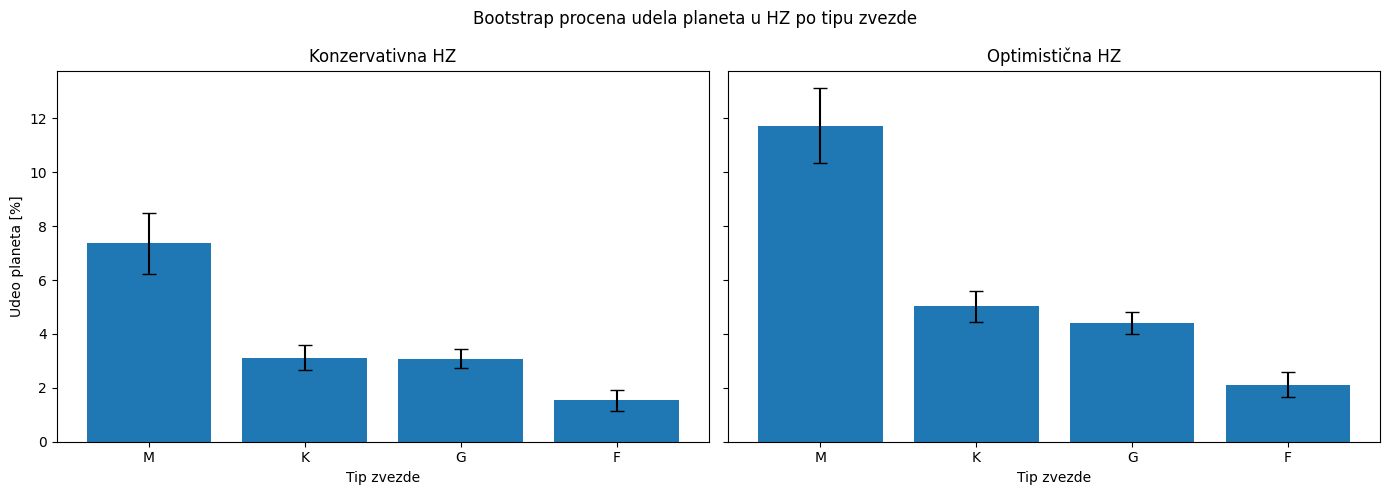

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

x = stellar_bootstrap_summary["stellar_type"]

axes[0].bar(
    x,
    stellar_bootstrap_summary["cons_mean_percent"],
    yerr=stellar_bootstrap_summary["cons_std_percent"],
    capsize=5
)
axes[0].set_xlabel("Tip zvezde")
axes[0].set_ylabel("Udeo planeta [%]")
axes[0].set_title("Konzervativna HZ")

axes[1].bar(
    x,
    stellar_bootstrap_summary["opt_mean_percent"],
    yerr=stellar_bootstrap_summary["opt_std_percent"],
    capsize=5
)
axes[1].set_xlabel("Tip zvezde")
axes[1].set_title("Optimistična HZ")

fig.suptitle("Bootstrap procena udela planeta u HZ po tipu zvezde")

plt.tight_layout()
plt.show()

Iz prethodno dobijene tabele može se primetiti da je pouzdanost procene različita za različite spektralne tipove što je i očekivano razmatrajući veličinu posmatranog uzorka. Dobijeno je da je za konzervativnu HZ kod M zvezda neodređenost oko $3.3$ puta veća nego kod G zvezda, slično i za optimističnu gde je $3.42$ puta.

## _Predlog za dalji rad_

Iako je apsolutni broj HZ kandidata najveći kod G zvezda, relativni udeo HZ kandidata najveći je kod M zvezda. Dalja analiza pokazuje zašto: tipične detektovane orbitalne udaljenosti su male za sve spektralne klase, jer je najviše planeta otkriveno tranzitnim metodom koji favorizuje što manje orbitalne periode, ali se Kopparapu HZ kod M zvezda nalazi mnogo bliže zvezdi nego kod F, G i K zvezda. Zbog toga su detektovane planete oko M zvezda relativno bliže svojoj habitabilnoj zoni, pa veći procenat njih upada u HZ interval.

Zbog toga je ideja za dalje korake proveriti da li se isti rezultat javlja ukoliko otklonimo uzorke dobijene metodom tranzita i posmatramo preostale. To će međutim verovatno biti mali uzorak kako je već broj iskoristivih smanjen na oko 5% otkrivenih pa će zbog toga statistička značajnost rezultata biti diskutabilna.